# 🧪 Case de Teste A/B em Python (Taxa de Conversão)
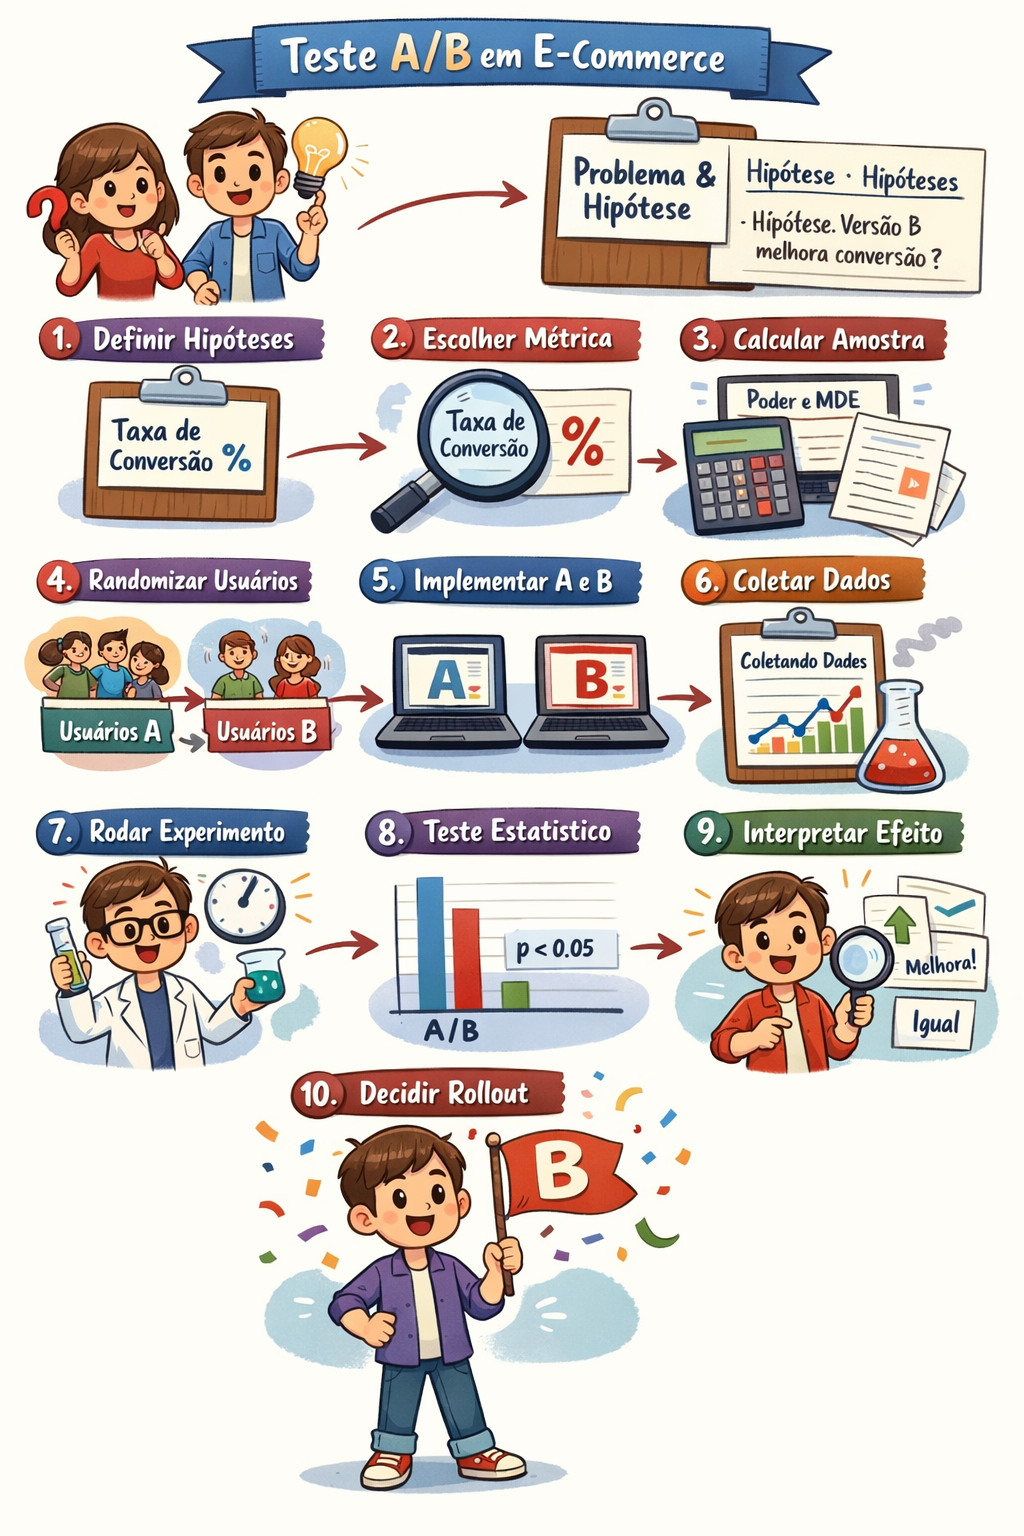

Cenário: Um e-commerce quer avaliar se uma nova página de produto (Versão B) melhora a taxa de conversão em relação à página atual (Versão A).

Nessa aula vamos seguir algumas etapas:
1. Definir problema e hipóteses
2. Escolher métrica primária
3. Calcular tamanho da amostra (poder e MDE)
4. Randomizar usuários
5. Implementar A e B
6. Coletar dados corretamente
7. Rodar o experimento
8. Testar estatisticamente
9. Interpretar efeito
10. Decidir rollout



Etapa 1: Definição do Problema

Antes de qualquer cálculo, defina:

✔️ População alvo

Ex.: usuários do app na página de pagamento.

✔️ Métrica primária

Ex.: taxa de conversão da compra.

✔️ Efeito mínimo detectável (MDE – Minimum Detectable Effect)

Ex.: “Quero detectar aumento mínimo de 1 ponto percentual”.

✔️ Hipóteses

H0: A taxa de conversão de A é igual à de B.

H1: A taxa de conversão de B é diferente (teste bilateral).



Etapa 2: Cálculo do Tamanho da Amostra

Precisamos definir:

- nível de significância α (geralmente 5%)

- poder 1−β (80% a 95%)

- taxa base

- MDE

📌 Exemplo (taxa base = 12%, MDE = 1 p.p.)

Vamos calcular em Python:

In [1]:
from statsmodels.stats.proportion import proportion_effectsize # Calcula o tamanho de efeito (effect size) para comparação entre duas proporções.
from statsmodels.stats.power import NormalIndPower # Tamanho mínimo de amostra

# Taxas
p1 = 0.12            # taxa A
p2 = 0.13            # taxa B = A + MDE (1p.p.)

# Calcula o effect size
effect_size = proportion_effectsize(p1, p2)

# Poder estatístico
analysis = NormalIndPower()

sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
)

sample_size


17163.025826592482

O experimento precisa de 17.163 usuários em cada grupo.

Etapa 3: Randomização

A aleatorização garante que os grupos sejam comparáveis.

Vamos randomizar 17.163 usuários por variante.

In [2]:
import numpy as np

np.random.seed(42)

n = 18000

grupo = np.random.choice(['A', 'B'], size=2*n)


In [3]:
# Simulando conversões

conversoes = []

for g in grupo:
    if g == 'A':
        conversoes.append(np.random.binomial(1, 0.10))
    else:
        conversoes.append(np.random.binomial(1, 0.12))

import pandas as pd

df = pd.DataFrame({
    'grupo': grupo,
    'converteu': conversoes
})

df.head()


,grupo,converteu
0,A,0
1,B,0
2,A,0
3,A,0
4,A,0


Verificando se os grupos ficaram equilibrados:

In [4]:
df['grupo'].value_counts()

,count
grupo,
B,18072
A,17928


In [5]:
df.groupby('grupo')['converteu'].mean()

,converteu
grupo,
A,0.104418
B,0.117253


✔️ Boas práticas de randomização

Sempre randomizar por usuário, nunca por sessão.

A randomização deve ser persistente (usuário deve permanecer no grupo).

Não randomizar por IP (causa viés).

Etapa 4: Implementação do Experimento

Aqui você garante que:

- O usuário veja apenas sua variante.

- Eventos sejam registrados corretamente (ex.: clique, compra, métricas).

Logs tenham:

  - user_id

  - grupo

  - timestamp

  - exposição

  - evento

  - variáveis de diagnóstico

Etapa 5: Execução e Janela de Observação

O experimento deve rodar até completar a amostra necessária.

Não parar antes só porque “parece estar dando certo”.

Controlar sazonalidade, horários e picos.

📌 Regra geral:
Execute até completar o tamanho amostral OU até terminar a janela de negócio.

In [6]:
# Análise do experimento
resumo = df.groupby('grupo')['converteu'].agg(['sum', 'count'])
resumo


,sum,count
grupo,,
A,1872,17928
B,2119,18072


6: Análise Estatística

Agora aplicamos o teste z para diferença de proporções.

In [7]:
from statsmodels.stats.proportion import proportions_ztest

conversions = resumo['sum'].values
nobs = resumo['count'].values

stat, pvalue = proportions_ztest(conversions, nobs, alternative='two-sided')


print("Estatística Z:", stat)
print("p-valor:", pvalue)


Estatística Z: -3.878443458576117
p-valor: 0.00010512695315871711


In [8]:
pvalue < 0.05

np.True_

✔ p < 0.05

✔ Diferença significativa

✔ Evidência de que B é melhor

In [9]:
taxa_A = df[df['grupo']=='A']['converteu'].mean()
taxa_B = df[df['grupo']=='B']['converteu'].mean()

uplift = taxa_B - taxa_A

print("Conversão A:", round(taxa_A,4))
print("Conversão B:", round(taxa_B,4))
print("Uplift:", round(uplift,4))


Conversão A: 0.1044
Conversão B: 0.1173
Uplift: 0.0128


Etapa 6: Estratégia de rollout

- Realizar rollout parcial (20% → 50% → 100%)

- Monitoramento pós-implementação

- Métricas secundárias (ex.: tempo de execução, NPS, reclamações)